# Loading our linear classifier for the CIFAR-10 dataset

Let's load our linear classification model for predicting image labels on the CIFAR-10 dataset.

But before that, let's initialize MindSpore 2.8.0 and ensure it is installed successfully.

In [1]:
import os

NOTEBOOK_USE_ASCEND = os.getenv('NOTEBOOK_USE_ASCEND', '0')
NOTEBOOK_USE_GPU = os.getenv('NOTEBOOK_USE_GPU', '0')
NOTEBOOK_USE_CPU = os.getenv('NOTEBOOK_USE_CPU', '0')
NOTEBOOK_CI_MODE = os.getenv('NOTEBOOK_CI_MODE', '0')

In [2]:
import mindspore

platform = 'Ascend'
if NOTEBOOK_USE_ASCEND == '1':
    platform = 'Ascend'
elif NOTEBOOK_USE_GPU == '1':
    platform = 'GPU'
elif NOTEBOOK_USE_CPU == '1' or NOTEBOOK_CI_MODE == '1':
    platform = 'CPU'
else:
    platform = 'Ascend'

mindspore.set_device(device_target=platform)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


## Loading the model for inference

Let's load our model from the MindIR export file `cifar10-linear-simple.mindir` in our previous notebook experiment for inference.

In [3]:
import mindspore.nn as nn

graph = mindspore.load('cifar10-linear-simple.mindir')
model = nn.GraphCell(graph)
model

GraphCell()

Load 10 samples from our validation set and compare the predicted vs. actual labels.

In [4]:
import mindspore.dataset as ds
import mindspore.dataset.vision as vision
from mindspore import dtype as mstype
import mindspore.ops as ops

dataset_dir = 'data/cifar-10-batches-bin/'
test_ds = ds.Cifar10Dataset(dataset_dir=dataset_dir, usage='test', shuffle=True)
image_transforms = [
    vision.Resize(size=(32, 32)),
    vision.Rescale(rescale=1/255, shift=0),
    vision.HWC2CHW()
]
test_ds = test_ds.map(operations=image_transforms, input_columns='image')
test_ds = test_ds.batch(batch_size=10)
X_samples, y_samples = next(test_ds.create_tuple_iterator())
X_samples = X_samples.astype(dtype=mstype.float16)
y_hat = ops.argmax(model(X_samples), dim=1).astype(dtype=mstype.uint32)
y_hat, y_samples

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

(Tensor(shape=[10], dtype=UInt32, value= [7, 4, 3, 6, 2, 1, 4, 6, 7, 1]),
 Tensor(shape=[10], dtype=UInt32, value= [7, 2, 1, 2, 0, 2, 4, 2, 7, 3]))

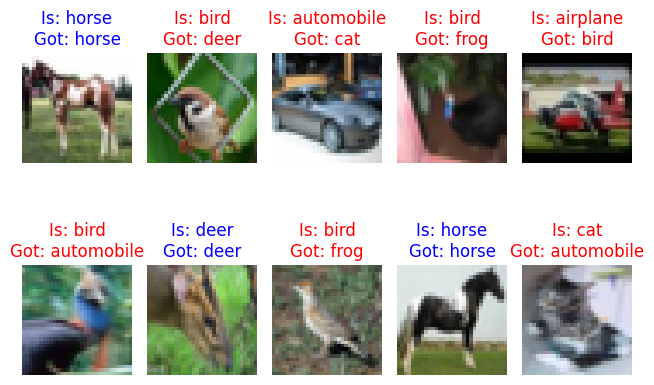

In [5]:
import matplotlib.pyplot as plt

LABELS = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    image = X_samples[axis_idx].astype(dtype=mstype.float32).asnumpy().transpose(1, 2, 0)
    expected = y_samples[axis_idx].item()
    actual = y_hat[axis_idx].item()
    match = expected == actual
    color = 'blue' if match else 'red'
    axis.set_title(f'Is: {LABELS[expected]}\nGot: {LABELS[actual]}', color=color)
    axis.imshow(image)
    axis.axis('off')
fig.tight_layout()
fig.show()

A bit better than random guessing but you get the idea ;-\)